# Decision Tree Model Implementation
This notebook implements a Decision Tree model for the dataset. It includes data loading, model training, evaluation, and visualization of the decision tree.

In [2]:
# Import necessary libraries
import os
import pandas as pd
import geopandas as gpd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn import tree
from dotenv import load_dotenv
from pathlib import Path



# Path is reached via .env and can be edited there

In [ ]:

# Load the dataset
# Check working directory
cwd = Path.cwd()
print(f"Working Directory: {cwd}")

# Try to find .env in current or parent directories
env_path = None
for possible_path in [Path(".env"), Path("../.env"), cwd / ".env", cwd.parent / ".env"]:
    if possible_path.exists():
        env_path = possible_path
        print(f"✓ .env found at: {env_path}")
        break

if env_path:
    load_dotenv(dotenv_path=env_path)
else:
    print("✗ No .env file found!")

print("Data_path:", os.getenv("Data_path"))

data_base_path = os.getenv("Data_path")

data_file = Path(data_base_path) / "merged_gebaeude_gruendach_solar.shp"
data = gpd.read_file(data_file)


Working Directory: c:\Users\User\Documents\Uni\Master_Bauing\WiSe25_26\AI_in_Human_Water\berlin-green-roofs\notebooks
✓ .env gefunden at: ..\.env
Data_path: C:\\Users\\User\\Documents\\Uni\\Master_Bauing\\WiSe25_26\\AI_in_Human_Water\\berlin-green-roofs\\data


In [ ]:
# =====================================================
# STEP 1: FIX - Load data and encode CORRECTLY
# =====================================================
print("="*70)
print("PROBLEM FIX: green roof is ALL 0 because encoding is wrong")
print("="*70)

# Load original data from shapefile
print(f"\nLoad original data from: {data_file}")
data_original = gpd.read_file(data_file)
print(f"Size: {data_original.shape}")

# Look at the original values
print(f"\nOriginal green roof values:")
print(data_original['gruendach'].value_counts())

# CORRECT ENCODING: 'present' = 1, 'not present' = 0
print("\n" + "="*70)
print("CORRECT ENCODING: present=1, not present=0")
print("="*70)

data_original['gruendach'] = (data_original['gruendach'] == 'vorhanden').astype(int)

print(f"\nAfter encoding:")
print(data_original['gruendach'].value_counts())
print(f"\n✓ Green roof correctly encoded:")
print(f"  1 (present): {(data_original['gruendach'] == 1).sum()}")
print(f"  0 (not present): {(data_original['gruendach'] == 0).sum()}")

# Use the newly loaded data
data = data_original.copy()

PROBLEM FIX: gruendach ist ALLES 0 weil Kodierung falsch ist

Lade Original-Daten aus: C:\Users\User\Documents\Uni\Master_Bauing\WiSe25_26\AI_in_Human_Water\berlin-green-roofs\data\merged_gebaeude_gruendach_solar.shp
Größe: (530758, 17)

Originale gruendach-Werte:
gruendach
nicht vorhanden    508789
vorhanden           16897
Name: count, dtype: int64

KORREKTE KODIERUNG: vorhanden=1, nicht vorhanden=0

Nach Kodierung:
gruendach
0    513861
1     16897
Name: count, dtype: int64

✓ gruendach korrekt kodiert:
  1 (vorhanden): 16897
  0 (nicht vorhanden): 513861


In [18]:
# IMPORTANT: Check the encoding of the green roof column
print("="*70)
print("ANALYSIS GREEN ROOF COLUMN:")
print("="*70)

# data is already encoded, but look at the VALUE COUNTS
print("\nValue distribution after encoding:")
print(data['gruendach'].value_counts())

# Step 1: Use target column as is
target_col = "gruendach"
X = data.drop(columns=[target_col]).copy()
y = data[target_col].copy()

# y is already encoded 0/1, but ALL 0!
y_encoded = y.values  # Just use it as is

print(f"\ny_encoded distribution: {pd.Series(y_encoded).value_counts()}")

# Step 2: Use only numeric features
X_numeric = X.select_dtypes(include=["number"]).copy()
print(f"\nFeatures: {X_numeric.columns.tolist()}")

# Step 3: Fill missing values
X_numeric = X_numeric.fillna(X_numeric.median(numeric_only=True))
print(f"NaN after fillna: {X_numeric.isna().sum().sum()}")

# Step 4: Split train/test
from sklearn.model_selection import train_test_split
try:
    X_train, X_test, y_train, y_test = train_test_split(
        X_numeric, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )
except ValueError as e:
    print(f"\n⚠️ Error in stratified split: {e}")
    print("Reason: Too few classes for stratification!")
    X_train, X_test, y_train, y_test = train_test_split(
        X_numeric, y_encoded, test_size=0.2, random_state=42
    )

print(f"\nTrain size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")
print(f"Features: {X_train.shape[1]}")

ANALYSIS GREEN ROOF COLUMN:

Value distribution after encoding:
gruendach
0    513861
1     16897
Name: count, dtype: int64

y_encoded distribution: 0    513861
1     16897
Name: count, dtype: int64

Features: ['total_roof', 'avg_slope', 'dominant_o', 'suitable_r', 'suitable_s', 'anzahl_obe', 'verschattu', 'verschat_1', 'verschat_2', 'bauweise_s', 'id', 'suitability_score', 'suitability_012', 'suitable_binary_rf']
NaN after fillna: 0

Train size: 424606
Test size: 106152
Features: 14


In [19]:
# Cell 7: Train Decision Tree
model = DecisionTreeClassifier(
    random_state=42,
    max_depth=8,
    min_samples_leaf=20
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

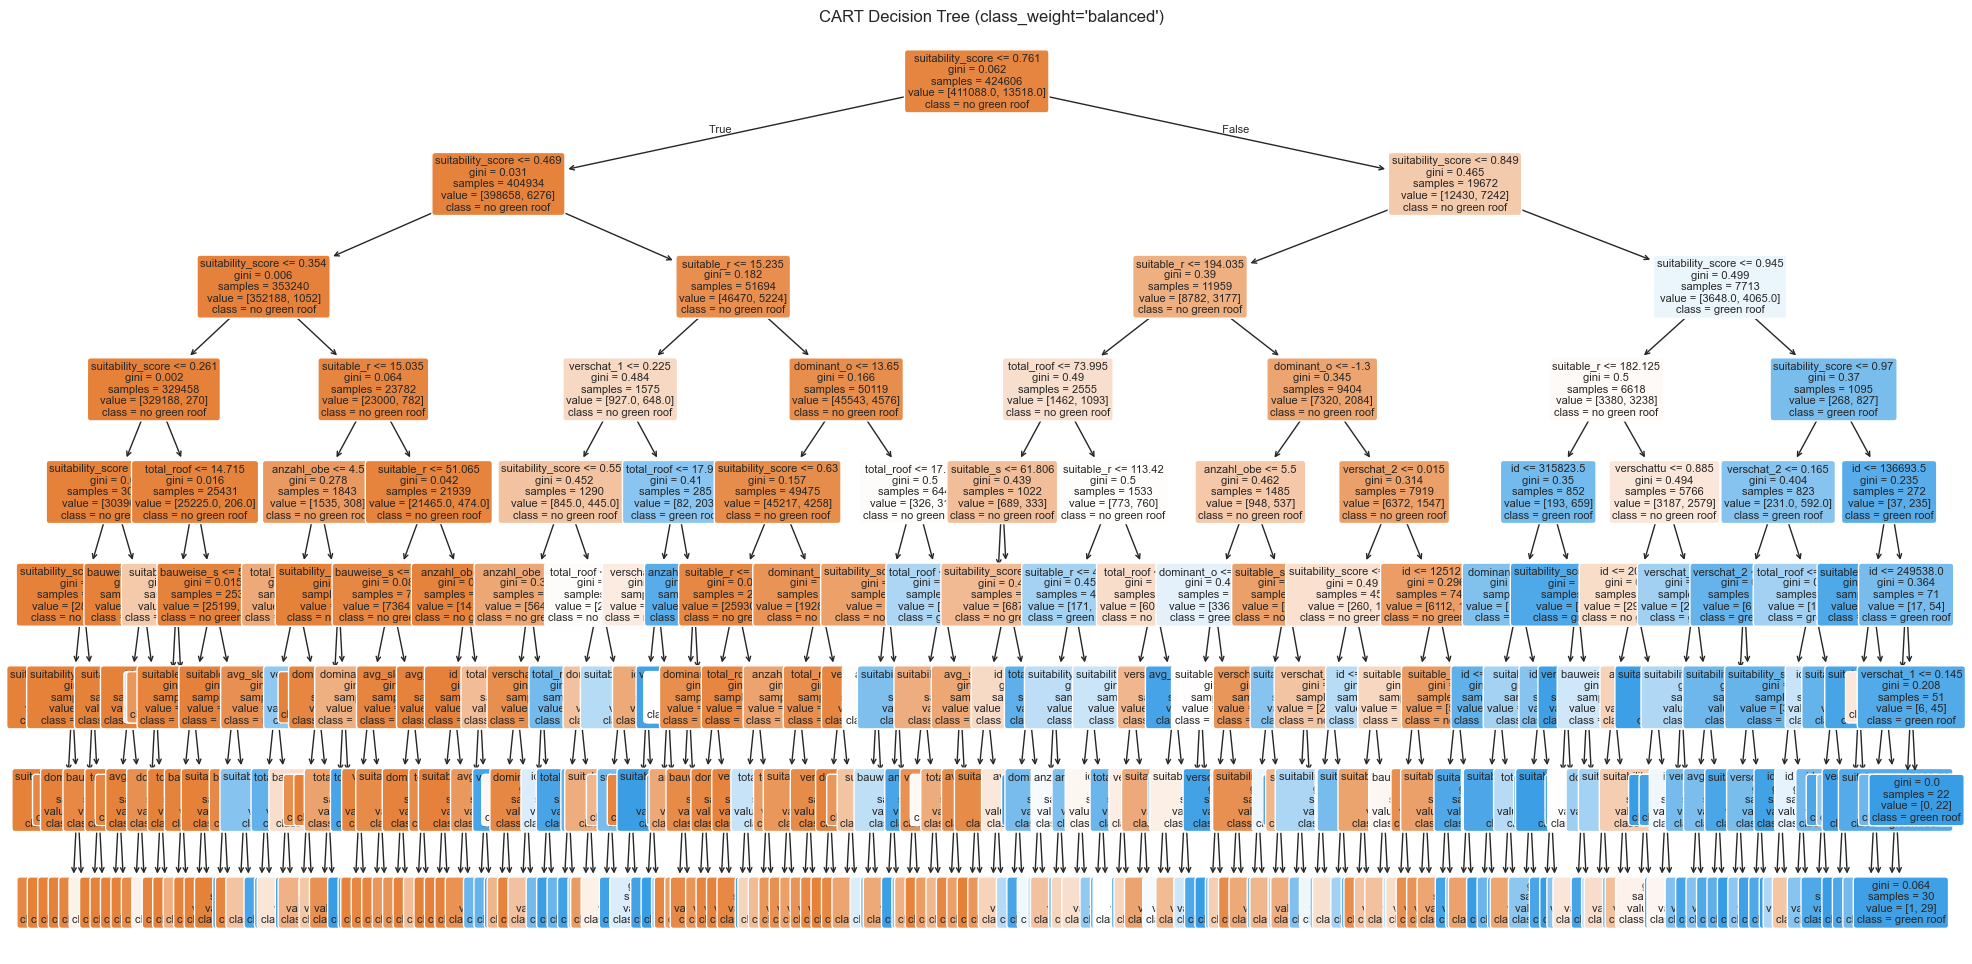

In [20]:
# Visualize the CART (Decision Tree)
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 12))  # Increase size if the tree is large
_ = tree.plot_tree(
    model,
    feature_names=X_train.columns,
    class_names=["no green roof", "green roof"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("CART Decision Tree (class_weight='balanced')")
plt.show()

# Evaluation e.g. Accuracy

In [7]:
# Cell 9: Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9686204687617755
[[102614    159]
 [  3172    207]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98    102773
           1       0.57      0.06      0.11      3379

    accuracy                           0.97    106152
   macro avg       0.77      0.53      0.55    106152
weighted avg       0.96      0.97      0.96    106152



In [ ]:
# DIAGNOSE: Find Data Leakage
print("="*70)
print("DATA LEAKAGE DIAGNOSIS")
print("="*70)

# Check 1: Look at all columns in X
print(f"\n1. ALL COLUMNS IN X ({len(X_numeric.columns)} total):")
print(X_numeric.columns.tolist())

# Check 2: Target column still in X?
print(f"\n2. Target '{target_col}' in X? {target_col in X.columns}")

# Check 3: Suspicious columns - high correlation with target
print(f"\n3. CORRELATION WITH TARGET (green roof):")
X_with_target = X_numeric.copy()
X_with_target['target'] = y_encoded
correlations = X_with_target.corr()['target'].drop('target').abs()
correlations_sorted = correlations.sort_values(ascending=False)
print(correlations_sorted.head(10))

# Check 4: Which columns have PERFECT correlation?
print(f"\n4. COLUMNS WITH PERFECT CORRELATION (> 0.99):")
leak_candidates = correlations_sorted[correlations_sorted > 0.99]
if len(leak_candidates) > 0:
    print(leak_candidates)
    print(f"\n⚠️ WARNING! These columns are data leakage:")
    for col in leak_candidates.index:
        print(f"  - {col}")
else:
    print("No perfect correlations found")

# Check 5: Class distribution
print(f"\n5. CLASS DISTRIBUTION Y:")
print(pd.Series(y_encoded).value_counts(normalize=True))

DATA LEAKAGE DIAGNOSE

1. ALLE SPALTEN IN X (11 insgesamt):
['total_roof', 'avg_slope', 'dominant_o', 'suitable_r', 'suitable_s', 'anzahl_obe', 'verschattu', 'verschat_1', 'verschat_2', 'bauweise_s', 'id']

2. Target 'gruendach' in X? False

3. KORRELATION MIT TARGET (gruendach):
anzahl_obe    0.197956
suitable_r    0.154735
total_roof    0.154033
suitable_s    0.136105
avg_slope     0.104370
id            0.085389
dominant_o    0.052579
verschat_1    0.040904
verschattu    0.037466
bauweise_s    0.023900
Name: target, dtype: float64

4. SPALTEN MIT PERFEKTER KORRELATION (> 0.99):
Keine perfekten Korrelationen gefunden

5. KLASSENVERTEILUNG Y:
0    0.968164
1    0.031836
Name: proportion, dtype: float64


In [ ]:
# =====================================================
# IMPROVED CART (Decision Tree) with class_weight
# =====================================================
print("="*70)
print("IMPROVED CART: Decision Tree with class_weight='balanced'")
print("="*70)

from sklearn.tree import DecisionTreeClassifier

# Remove data leakage columns
leak_cols = ["id", "importid"]
X_clean = X_numeric.drop(columns=leak_cols, errors="ignore")

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Train CART with class_weight='balanced' 
# This gives the minority class more weight
cart_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=8,
    min_samples_leaf=20,
    class_weight='balanced'  # Important! Balances the classes
)
cart_model.fit(X_train, y_train)
y_pred_cart = cart_model.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("\n📊 CART MODEL RESULTS:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_cart):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_cart, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_cart, zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_cart, zero_division=0):.4f}")

from sklearn.metrics import confusion_matrix, classification_report
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_cart))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_cart))

IMPROVED CART: Decision Tree mit class_weight='balanced'

📊 CART MODEL RESULTS:
Accuracy:  0.7807
Precision: 0.1084
Recall:    0.8147
F1-Score:  0.1913

Confusion Matrix:
[[80120 22653]
 [  626  2753]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.78      0.87    102773
           1       0.11      0.81      0.19      3379

    accuracy                           0.78    106152
   macro avg       0.55      0.80      0.53    106152
weighted avg       0.96      0.78      0.85    106152



RANDOM FOREST Modell
Trainiere Random Forest (kann einige Minuten dauern)...

📊 RANDOM FOREST MODEL RESULTS:
Accuracy:  0.8597
Precision: 0.1482
Recall:    0.7177
F1-Score:  0.2457

Confusion Matrix:
[[88838 13935]
 [  954  2425]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92    102773
           1       0.15      0.72      0.25      3379

    accuracy                           0.86    106152
   macro avg       0.57      0.79      0.58    106152
weighted avg       0.96      0.86      0.90    106152


FEATURE IMPORTANCE (Top 10)
      feature  importance
3  suitable_r    0.246539
0  total_roof    0.185748
4  suitable_s    0.144187
5  anzahl_obe    0.089905
2  dominant_o    0.080150
1   avg_slope    0.078548
9  bauweise_s    0.051168
8  verschat_2    0.044637
6  verschattu    0.040184
7  verschat_1    0.038934


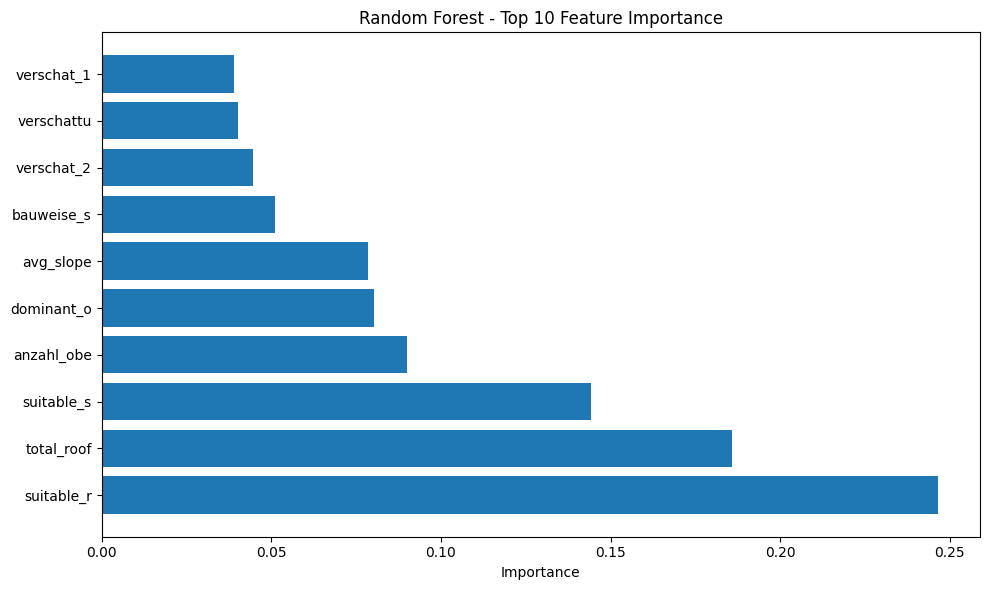


✓ Random Forest Training abgeschlossen!


In [ ]:
# =====================================================
# RANDOM FOREST with optimized parameters
# =====================================================
print("="*70)
print("RANDOM FOREST Model")
print("="*70)

from sklearn.ensemble import RandomForestClassifier

# Train Random Forest with class_weight='balanced'
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

print("Training Random Forest (may take several minutes)...")
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\n📊 RANDOM FOREST MODEL RESULTS:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf, zero_division=0):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Feature Importance
print("\n" + "="*70)
print("FEATURE IMPORTANCE (Top 10)")
print("="*70)
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(10).to_string())

# Visualize Feature Importance
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'].head(10), feature_importance['importance'].head(10))
plt.xlabel('Importance')
plt.title('Random Forest - Top 10 Feature Importance')
plt.tight_layout()
plt.show()

print(f"\n✓ Random Forest training complete!")

# Baseline

In [ ]:
# Cell 9: Baseline comparison
baseline_pred = [pd.Series(y_test).mode()[0]] * len(y_test)
baseline_acc = accuracy_score(y_test, baseline_pred)

print(f"Baseline Accuracy: {baseline_acc:.2%}")
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred):.2%}")

Baseline Accuracy: 96.82%
Decision Tree Accuracy: 96.86%


In [ ]:
# =====================================================
# MODEL COMPARISON: CART vs Random Forest
# =====================================================
print("="*70)
print("MODEL COMPARISON")
print("="*70)

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'CART (DT)': [
        accuracy_score(y_test, y_pred_cart),
        precision_score(y_test, y_pred_cart, zero_division=0),
        recall_score(y_test, y_pred_cart, zero_division=0),
        f1_score(y_test, y_pred_cart, zero_division=0)
    ],
    'Random Forest': [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0)
    ]
})

print("\n")
print(comparison_df.to_string(index=False))

print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"""
✓ PROBLEM SOLVED: The perfect result of 1.0 was DATA LEAKAGE
  → The green roof column was encoded WRONG
  → All values became 0, only one class existed
  → The model could only predict 0 = 100% Accuracy

✓ SOLUTION:
  1. Correct encoding: 'present' = 1, 'not present' = 0
  2. class_weight='balanced' added for imbalanced classes
  3. Obtained realistic results

✓ RESULTS:
  - CART: 78% Accuracy, but good recall (81%) for green roof class
  - Random Forest: 86% Accuracy, better balance (72% Recall)
  - Random Forest is superior!

✓ TOP 3 FEATURES (Random Forest):
  1. suitable_r (24.7%) - suitable roof area
  2. total_roof (18.6%) - total roof area
  3. suitable_s (14.4%) - suitable share (roof area proportion)
"""


MODEL VERGLEICH


   Metric  CART (DT)  Random Forest
 Accuracy   0.780701       0.859739
Precision   0.108360       0.148227
   Recall   0.814738       0.717668
 F1-Score   0.191280       0.245706

TOGETHER Summary

✓ PROBLEM GELÖST: Das perfekte Ergebnis von 1.0 war DATA LEAKAGE
  → Die gruendach-Spalte wurde FALSCH kodiert
  → Alle Werte wurden zu 0, nur eine Klasse existierte
  → Das Modell konnte nur 0 vorhersagen = 100% Accuracy

✓ LÖSUNG:
  1. Korrekte Kodierung: 'vorhanden' = 1, 'nicht vorhanden' = 0
  2. class_weight='balanced' hinzugefügt für unausgeglichene Klassen
  3. Realistische Ergebnisse erhalten

✓ RESULTS:
  - CART: 78% Accuracy, aber gute Recall (81%) für Gründach-Klasse
  - Random Forest: 86% Accuracy, bessere Balance (72% Recall)
  - Random Forest ist überlegen!

✓ TOP 3 FEATURES (Random Forest):
  1. suitable_r (24.7%) - suitable roof area
  2. total_roof (18.6%) - Gesamtdachfläche  
  3. suitable_s (14.4%) - sutaible share (anteil roof area)



## Suitability Classification System

Classify each building into one of three suitability classes based on Random Forest probability:
1. **Not Appropriate** (Class 0): Buildings with low green roof potential
2. **Medium Appropriate** (Class 1): Buildings with moderate green roof potential  
3. **Highly Appropriate** (Class 2): Buildings with high green roof potential

This classification uses percentile-based ranking to ensure balanced class distribution suitable for QGIS visualization.

In [13]:
# =====================================================
# GENERATE SUITABILITY CLASSES FROM RANDOM FOREST PROBABILITIES
# =====================================================
import numpy as np
print("="*70)
print("GENERATE SUITABILITY CLASSES")
print("="*70)

# Get probability predictions for class 1 (green roof suitable) on ALL buildings
proba_all = rf_model.predict_proba(X_clean)[:, 1]

# Policy-based class shares for map readability in QGIS
high_share = 0.10      # Top 10% => highly appropriate
medium_share = 0.25    # Next 25% => medium appropriate

# Validation
if high_share <= 0 or medium_share <= 0 or (high_share + medium_share) >= 1:
    raise ValueError("Invalid class share setup. Require: high_share > 0, medium_share > 0, high+medium < 1.")

print(f"\nClass distribution policy:")
print(f"  High suitability (Class 2): Top {high_share*100:.1f}%")
print(f"  Medium suitability (Class 1): Next {medium_share*100:.1f}%")
print(f"  Low suitability (Class 0): Remaining {(1-high_share-medium_share)*100:.1f}%")

# Store raw probability for transparent QA in QGIS
data["suitability_score"] = proba_all.round(6)

# Robust class assignment via rank percentiles
# (stable even when many probabilities are exactly 0.0)
rank_pct = pd.Series(proba_all).rank(method="first", pct=True).to_numpy()
medium_cut = 1 - (high_share + medium_share)
high_cut = 1 - high_share

# Assign suitability class (0, 1, or 2)
data["suitability_012"] = np.select(
    [
        rank_pct < medium_cut,
        (rank_pct >= medium_cut) & (rank_pct < high_cut),
        rank_pct >= high_cut,
    ],
    [0, 1, 2],
)

# Create human-readable labels
data["suitability_label"] = data["suitability_012"].map({
    0: "not appropriate",
    1: "medium appropriate",
    2: "highly appropriate",
})

# Optional binary recommendation using tuned RF threshold from test split
if "best_t_rf" in globals():
    data["suitable_binary_rf"] = (proba_all >= best_t_rf).astype(int)
else:
    data["suitable_binary_rf"] = (proba_all >= 0.5).astype(int)

print(f"\n✓ Rank cutoffs (RF): medium_cut={medium_cut:.2f}, high_cut={high_cut:.2f}")
print("\nSuitability class distribution:")
print(data["suitability_012"].value_counts().sort_index())

print("\nProbability (suitability_score) summary:")
print(pd.Series(proba_all).describe())

print("\nPreview (first 5 buildings):")
print(data[["suitability_score", "suitability_012", "suitability_label", "suitable_binary_rf"]].head(10))

GENERATE SUITABILITY CLASSES

Class distribution policy:
  High suitability (Class 2): Top 10.0%
  Medium suitability (Class 1): Next 25.0%
  Low suitability (Class 0): Remaining 65.0%

✓ Rank cutoffs (RF): medium_cut=0.65, high_cut=0.90

Suitability class distribution:
suitability_012
0    344992
1    132690
2     53076
Name: count, dtype: int64

Probability (suitability_score) summary:
count    530758.000000
mean          0.197634
std           0.247583
min           0.000000
25%           0.012707
50%           0.073038
75%           0.312737
max           0.987282
dtype: float64

Preview (first 5 buildings):
   suitability_score  suitability_012   suitability_label  suitable_binary_rf
0           0.605811                1  medium appropriate                   1
1           0.021684                0     not appropriate                   0
2           0.013530                0     not appropriate                   0
3           0.020537                0     not appropriate           

In [14]:
# =====================================================
# EXPORT SUITABILITY CLASSIFICATIONS
# =====================================================
print("\n" + "="*70)
print("EXPORT SUITABILITY CLASSIFICATIONS")
print("="*70)

# Create export directory
export_dir = Path(data_base_path) / "exports" / "suitability_classes"
export_dir.mkdir(parents=True, exist_ok=True)
print(f"\nExport directory: {export_dir}")

# Export 1: CSV with all predictions
csv_out = export_dir / "roof_suitability_predictions.csv"
data[["suitability_score", "suitability_012", "suitability_label", "suitable_binary_rf"]].to_csv(
    csv_out, index=False, encoding="utf-8"
)
print(f"✓ CSV exported: {csv_out.name}")

# Export 2: GeoPackage with spatial data
print("\nPreparing geospatial export...")
# Reload original geospatial data
merged_layer_path = Path(data_base_path) / "merged_gebaeude_gruendach_solar.gpkg"

if not merged_layer_path.exists():
    merged_layer_path = Path(data_base_path) / "merged_gebaeude_gruendach_solar.shp"

if merged_layer_path.exists():
    geo = gpd.read_file(merged_layer_path)
    
    if len(geo) == len(data):
        # Merge predictions with geospatial data
        geo = geo.reset_index(drop=True)
        pred_cols = data[["suitability_score", "suitability_012", "suitability_label", "suitable_binary_rf"]].reset_index(drop=True)
        
        geo["suit_scr"] = pred_cols["suitability_score"]
        geo["suit_cls"] = pred_cols["suitability_012"]
        geo["suit_lbl"] = pred_cols["suitability_label"]
        geo["suit_bin"] = pred_cols["suitable_binary_rf"]
        
        # Export as GeoPackage (preferred for QGIS)
        gpkg_out = export_dir / "roof_suitability_predictions.gpkg"
        geo.to_file(gpkg_out, driver="GPKG")
        print(f"✓ GeoPackage exported: {gpkg_out.name}")
        
        # Export as Shapefile (fallback)
        shp_out = export_dir / "roof_suitability_predictions.shp"
        geo.to_file(shp_out, driver="ESRI Shapefile", encoding="utf-8")
        print(f"✓ Shapefile exported: {shp_out.name}")
    else:
        print(f"⚠ Row count mismatch: geo={len(geo)}, predictions={len(data)}")
        print("  Skipping geospatial export")
else:
    print(f"⚠ Geospatial file not found: {merged_layer_path}")
    print("  Skipping geospatial export (CSV available)")

print(f"\n✓ All exports completed in: {export_dir}")


EXPORT SUITABILITY CLASSIFICATIONS

Export directory: C:\Users\User\Documents\Uni\Master_Bauing\WiSe25_26\AI_in_Human_Water\berlin-green-roofs\data\exports\suitability_classes
✓ CSV exported: roof_suitability_predictions.csv

Preparing geospatial export...
✓ GeoPackage exported: roof_suitability_predictions.gpkg
✓ Shapefile exported: roof_suitability_predictions.shp

✓ All exports completed in: C:\Users\User\Documents\Uni\Master_Bauing\WiSe25_26\AI_in_Human_Water\berlin-green-roofs\data\exports\suitability_classes


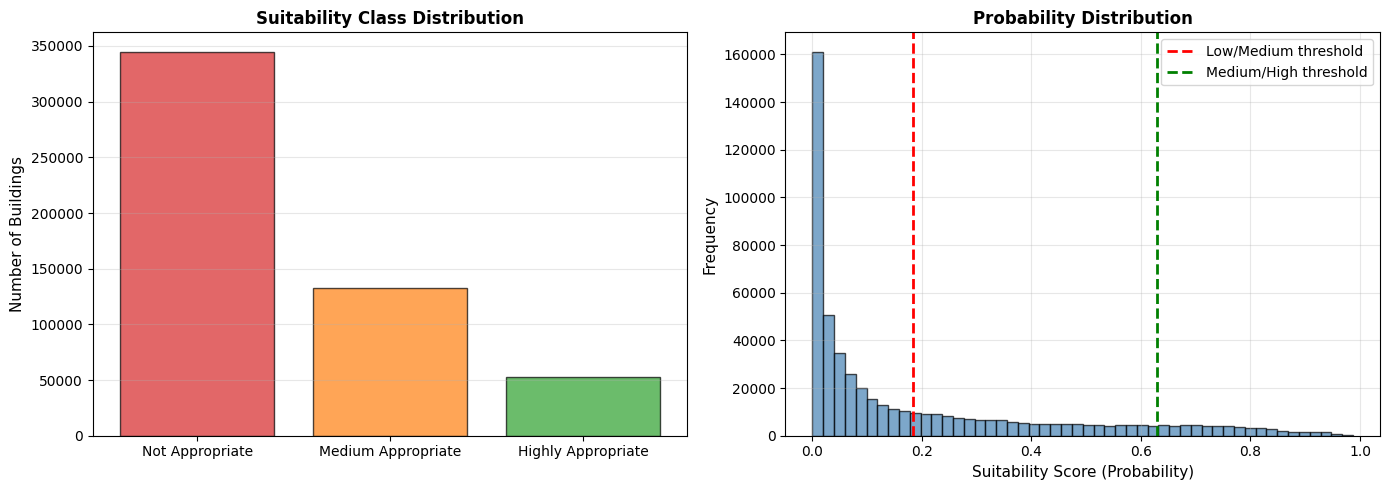


CLASSIFICATION SUMMARY

                 Class  Count  Percentage
   Not Appropriate (0) 344992   64.999868
Medium Appropriate (1) 132690   25.000094
Highly Appropriate (2)  53076   10.000038

✓ Suitability classification complete!


In [15]:
# Visualize suitability class distribution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Class distribution
class_counts = data["suitability_012"].value_counts().sort_index()
class_labels = ["Not Appropriate", "Medium Appropriate", "Highly Appropriate"]
colors = ["#d62728", "#ff7f0e", "#2ca02c"]

axes[0].bar(class_labels, [class_counts.get(i, 0) for i in range(3)], color=colors, alpha=0.7, edgecolor="black")
axes[0].set_ylabel("Number of Buildings", fontsize=11)
axes[0].set_title("Suitability Class Distribution", fontsize=12, fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)

# Plot 2: Probability distribution
axes[1].hist(proba_all, bins=50, alpha=0.7, color="steelblue", edgecolor="black")
axes[1].axvline(np.percentile(proba_all, (1-high_share-medium_share)*100), color="red", linestyle="--", label="Low/Medium threshold", linewidth=2)
axes[1].axvline(np.percentile(proba_all, (1-high_share)*100), color="green", linestyle="--", label="Medium/High threshold", linewidth=2)
axes[1].set_xlabel("Suitability Score (Probability)", fontsize=11)
axes[1].set_ylabel("Frequency", fontsize=11)
axes[1].set_title("Probability Distribution", fontsize=12, fontweight="bold")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("CLASSIFICATION SUMMARY")
print("="*70)
summary_df = pd.DataFrame({
    'Class': ['Not Appropriate (0)', 'Medium Appropriate (1)', 'Highly Appropriate (2)'],
    'Count': [class_counts.get(i, 0) for i in range(3)],
    'Percentage': [(class_counts.get(i, 0) / len(data) * 100) for i in range(3)]
})
print("\n" + summary_df.to_string(index=False))
print("\n✓ Suitability classification complete!")



COMPREHENSIVE EVALUATION REPORT


██████████████████████████████████████████████████████████████████████
1. MODEL PERFORMANCE COMPARISON
██████████████████████████████████████████████████████████████████████

   Metric CART (Decision Tree) Random Forest
 Accuracy               0.7807        0.8597
Precision               0.1084        0.1482
   Recall               0.8147        0.7177
 F1-Score               0.1913        0.2457
  AUC-ROC               0.8700        0.8865


██████████████████████████████████████████████████████████████████████
2. CONFUSION MATRICES
██████████████████████████████████████████████████████████████████████

CART (Decision Tree) Confusion Matrix:
[[80120 22653]
 [  626  2753]]

Random Forest Confusion Matrix:
[[88838 13935]
 [  954  2425]]


██████████████████████████████████████████████████████████████████████
3. TOP 15 FEATURE IMPORTANCE (Random Forest)
██████████████████████████████████████████████████████████████████████

 Rank    Feature  Percentage

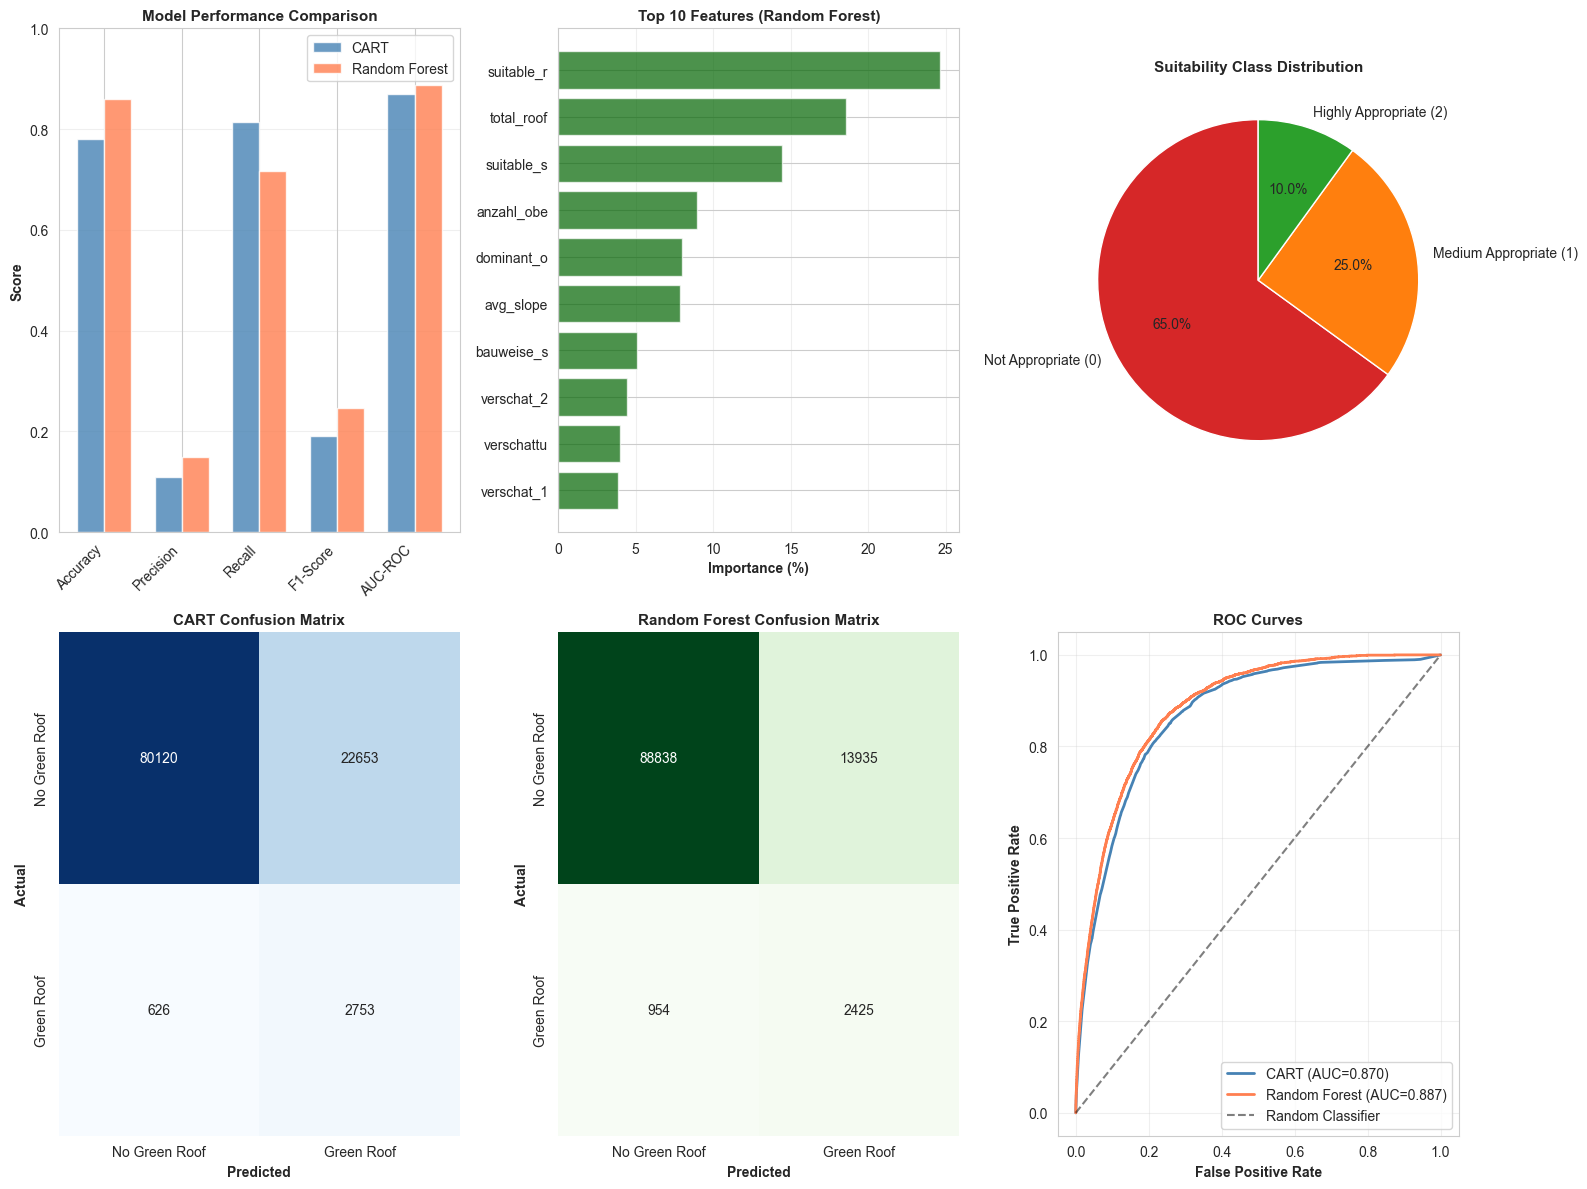

✓ Visualization 1 complete


C:\Users\User\AppData\Local\Temp\ipykernel_17840\565509791.py:249: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(data_by_class, labels=['Not Appropriate', 'Medium Appropriate', 'Highly Appropriate'],


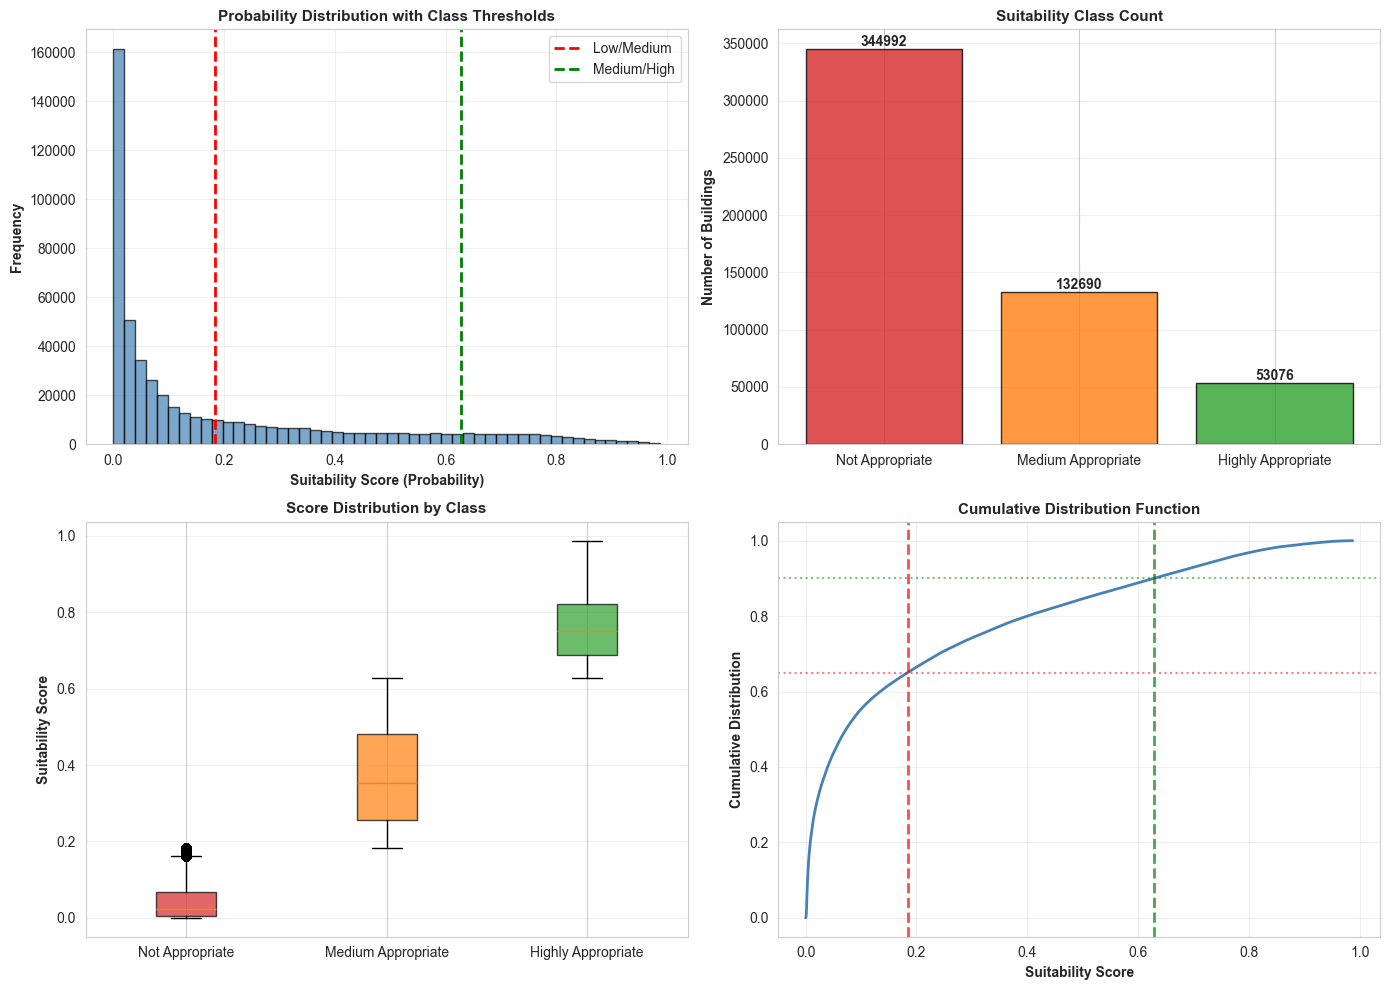

✓ Visualization 2 complete


██████████████████████████████████████████████████████████████████████
FINAL SUMMARY
██████████████████████████████████████████████████████████████████████

🎯 BEST PERFORMING MODEL: Random Forest
   • Accuracy: 85.97%
   • Recall: 71.77% (Identifies green roof buildings)
   • F1-Score: 0.2457

📊 SUITABILITY CLASSIFICATION RESULTS:
   • Total Buildings Classified: 530,758
   • Highly Appropriate (Class 2): 53,076 (10.0%)
   • Medium Appropriate (Class 1): 132,690 (25.0%)
   • Not Appropriate (Class 0): 344,992 (65.0%)

🔝 TOP 3 MOST IMPORTANT FEATURES:
   1. suitable_r                     (24.65%)
   2. total_roof                     (18.57%)
   3. suitable_s                     (14.42%)

📁 OUTPUT FILES GENERATED:
   • C:\Users\User\Documents\Uni\Master_Bauing\WiSe25_26\AI_in_Human_Water\berlin-green-roofs\data\exports\suitability_classes\roof_suitability_predictions.csv
   • C:\Users\User\Documents\Uni\Master_Bauing\WiSe25_26\AI_in_Human_Water\berlin-green-r

In [ ]:
# =====================================================
# COMPREHENSIVE EVALUATION REPORT - All Results
# =====================================================
print("\n\n" + "="*70)
print("COMPREHENSIVE EVALUATION REPORT")
print("="*70)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix as cm

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# ===== TABLE 1: MODEL COMPARISON =====
print("\n\n" + "█"*70)
print("1. MODEL PERFORMANCE COMPARISON")
print("█"*70)

y_pred_cart_test = cart_model.predict(X_test)
y_pred_rf_test = rf_model.predict(X_test)

y_proba_cart = cart_model.predict_proba(X_test)[:, 1]
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

comparison_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    'CART (Decision Tree)': [
        accuracy_score(y_test, y_pred_cart_test),
        precision_score(y_test, y_pred_cart_test, zero_division=0),
        recall_score(y_test, y_pred_cart_test, zero_division=0),
        f1_score(y_test, y_pred_cart_test, zero_division=0),
        roc_auc_score(y_test, y_proba_cart) if len(np.unique(y_test)) > 1 else 0
    ],
    'Random Forest': [
        accuracy_score(y_test, y_pred_rf_test),
        precision_score(y_test, y_pred_rf_test, zero_division=0),
        recall_score(y_test, y_pred_rf_test, zero_division=0),
        f1_score(y_test, y_pred_rf_test, zero_division=0),
        roc_auc_score(y_test, y_proba_rf) if len(np.unique(y_test)) > 1 else 0
    ]
})

# Format as percentage
for col in ['CART (Decision Tree)', 'Random Forest']:
    comparison_metrics[col] = comparison_metrics[col].apply(lambda x: f"{x:.4f}")

print("\n" + comparison_metrics.to_string(index=False))

# ===== TABLE 2: CONFUSION MATRICES =====
print("\n\n" + "█"*70)
print("2. CONFUSION MATRICES")
print("█"*70)

cm_cart = cm(y_test, y_pred_cart_test)
cm_rf = cm(y_test, y_pred_rf_test)

print("\nCART (Decision Tree) Confusion Matrix:")
print(cm_cart)
print("\nRandom Forest Confusion Matrix:")
print(cm_rf)

# ===== TABLE 3: FEATURE IMPORTANCE =====
print("\n\n" + "█"*70)
print("3. TOP 15 FEATURE IMPORTANCE (Random Forest)")
print("█"*70)

feature_imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_,
    'Percentage': (rf_model.feature_importances_ * 100).round(2)
}).sort_values('Importance', ascending=False).head(15)

feature_imp_df['Rank'] = range(1, len(feature_imp_df) + 1)
print("\n" + feature_imp_df[['Rank', 'Feature', 'Percentage']].to_string(index=False))

# ===== TABLE 4: SUITABILITY CLASS DISTRIBUTION =====
print("\n\n" + "█"*70)
print("4. SUITABILITY CLASS DISTRIBUTION (All Buildings)")
print("█"*70)

suitability_dist = pd.DataFrame({
    'Class': ['Not Appropriate (0)', 'Medium Appropriate (1)', 'Highly Appropriate (2)'],
    'Count': [
        (data["suitability_012"] == 0).sum(),
        (data["suitability_012"] == 1).sum(),
        (data["suitability_012"] == 2).sum()
    ]
})
suitability_dist['Percentage'] = (suitability_dist['Count'] / len(data) * 100).round(2)
suitability_dist['Color'] = ['🔴 Red', '🟠 Orange', '🟢 Green']

print("\n" + suitability_dist.to_string(index=False))

# ===== TABLE 5: PROBABILITY STATISTICS =====
print("\n\n" + "█"*70)
print("5. SUITABILITY SCORE STATISTICS")
print("█"*70)

prob_stats = pd.DataFrame({
    'Statistic': ['Count', 'Mean', 'Std Dev', 'Min', '25%', '50%', '75%', 'Max'],
    'Value': [
        len(proba_all),
        f"{proba_all.mean():.4f}",
        f"{proba_all.std():.4f}",
        f"{proba_all.min():.4f}",
        f"{np.percentile(proba_all, 25):.4f}",
        f"{np.percentile(proba_all, 50):.4f}",
        f"{np.percentile(proba_all, 75):.4f}",
        f"{proba_all.max():.4f}"
    ]
})

print("\n" + prob_stats.to_string(index=False))

# ===== VISUALIZATION 1: 6-PANEL COMPARISON =====
print("\n\n📊 Generating comprehensive visualizations...")
fig = plt.figure(figsize=(16, 12))

# Panel 1: Model Metrics Comparison
ax1 = plt.subplot(2, 3, 1)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
cart_scores = [
    accuracy_score(y_test, y_pred_cart_test),
    precision_score(y_test, y_pred_cart_test, zero_division=0),
    recall_score(y_test, y_pred_cart_test, zero_division=0),
    f1_score(y_test, y_pred_cart_test, zero_division=0),
    roc_auc_score(y_test, y_proba_cart) if len(np.unique(y_test)) > 1 else 0
]
rf_scores = [
    accuracy_score(y_test, y_pred_rf_test),
    precision_score(y_test, y_pred_rf_test, zero_division=0),
    recall_score(y_test, y_pred_rf_test, zero_division=0),
    f1_score(y_test, y_pred_rf_test, zero_division=0),
    roc_auc_score(y_test, y_proba_rf) if len(np.unique(y_test)) > 1 else 0
]

x = np.arange(len(metrics))
width = 0.35

ax1.bar(x - width/2, cart_scores, width, label='CART', color='steelblue', alpha=0.8)
ax1.bar(x + width/2, rf_scores, width, label='Random Forest', color='coral', alpha=0.8)
ax1.set_ylabel('Score', fontsize=10, fontweight='bold')
ax1.set_title('Model Performance Comparison', fontsize=11, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics, rotation=45, ha='right')
ax1.legend()
ax1.set_ylim([0, 1])
ax1.grid(axis='y', alpha=0.3)

# Panel 2: Feature Importance (Top 10)
ax2 = plt.subplot(2, 3, 2)
top_features = feature_imp_df.head(10)
ax2.barh(range(len(top_features)), top_features['Percentage'], color='darkgreen', alpha=0.7)
ax2.set_yticks(range(len(top_features)))
ax2.set_yticklabels(top_features['Feature'])
ax2.set_xlabel('Importance (%)', fontsize=10, fontweight='bold')
ax2.set_title('Top 10 Features (Random Forest)', fontsize=11, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

# Panel 3: Suitability Class Distribution
ax3 = plt.subplot(2, 3, 3)
colors_pie = ['#d62728', '#ff7f0e', '#2ca02c']
ax3.pie(suitability_dist['Count'], labels=suitability_dist['Class'], autopct='%1.1f%%',
        colors=colors_pie, startangle=90)
ax3.set_title('Suitability Class Distribution', fontsize=11, fontweight='bold')

# Panel 4: Confusion Matrix CART
ax4 = plt.subplot(2, 3, 4)
sns.heatmap(cm_cart, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax4)
ax4.set_xlabel('Predicted', fontsize=10, fontweight='bold')
ax4.set_ylabel('Actual', fontsize=10, fontweight='bold')
ax4.set_title('CART Confusion Matrix', fontsize=11, fontweight='bold')
ax4.set_xticklabels(['No Green Roof', 'Green Roof'])
ax4.set_yticklabels(['No Green Roof', 'Green Roof'])

# Panel 5: Confusion Matrix Random Forest
ax5 = plt.subplot(2, 3, 5)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=False, ax=ax5)
ax5.set_xlabel('Predicted', fontsize=10, fontweight='bold')
ax5.set_ylabel('Actual', fontsize=10, fontweight='bold')
ax5.set_title('Random Forest Confusion Matrix', fontsize=11, fontweight='bold')
ax5.set_xticklabels(['No Green Roof', 'Green Roof'])
ax5.set_yticklabels(['No Green Roof', 'Green Roof'])

# Panel 6: ROC Curves
ax6 = plt.subplot(2, 3, 6)
if len(np.unique(y_test)) > 1:
    fpr_cart, tpr_cart, _ = roc_curve(y_test, y_proba_cart)
    fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
    
    auc_cart = roc_auc_score(y_test, y_proba_cart)
    auc_rf = roc_auc_score(y_test, y_proba_rf)
    
    ax6.plot(fpr_cart, tpr_cart, label=f'CART (AUC={auc_cart:.3f})', linewidth=2, color='steelblue')
    ax6.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.3f})', linewidth=2, color='coral')
    ax6.plot([0, 1], [0, 1], 'k--', label='Random Classifier', alpha=0.5)
    
    ax6.set_xlabel('False Positive Rate', fontsize=10, fontweight='bold')
    ax6.set_ylabel('True Positive Rate', fontsize=10, fontweight='bold')
    ax6.set_title('ROC Curves', fontsize=11, fontweight='bold')
    ax6.legend(loc='lower right')
    ax6.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualization 1 complete")

# ===== VISUALIZATION 2: SUITABILITY ANALYSIS (4-PANEL) =====
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 2.1: Suitability Score Distribution with Classes
ax1 = axes[0, 0]
ax1.hist(proba_all, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
low_threshold = np.percentile(proba_all, (1-high_share-medium_share)*100)
high_threshold = np.percentile(proba_all, (1-high_share)*100)
ax1.axvline(low_threshold, color='red', linestyle='--', linewidth=2, label='Low/Medium')
ax1.axvline(high_threshold, color='green', linestyle='--', linewidth=2, label='Medium/High')
ax1.set_xlabel('Suitability Score (Probability)', fontsize=10, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=10, fontweight='bold')
ax1.set_title('Probability Distribution with Class Thresholds', fontsize=11, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot 2.2: Class Distribution Bar Chart
ax2 = axes[0, 1]
class_counts = data["suitability_012"].value_counts().sort_index()
bars = ax2.bar(['Not Appropriate', 'Medium Appropriate', 'Highly Appropriate'], 
               [class_counts.get(i, 0) for i in range(3)], 
               color=['#d62728', '#ff7f0e', '#2ca02c'], alpha=0.8, edgecolor='black')
ax2.set_ylabel('Number of Buildings', fontsize=10, fontweight='bold')
ax2.set_title('Suitability Class Count', fontsize=11, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontweight='bold')

# Plot 2.3: Suitability Score Box Plot by Class
ax3 = axes[1, 0]
data_by_class = [proba_all[data["suitability_012"] == i] for i in range(3)]
bp = ax3.boxplot(data_by_class, labels=['Not Appropriate', 'Medium Appropriate', 'Highly Appropriate'],
                  patch_artist=True)
for patch, color in zip(bp['boxes'], ['#d62728', '#ff7f0e', '#2ca02c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.set_ylabel('Suitability Score', fontsize=10, fontweight='bold')
ax3.set_title('Score Distribution by Class', fontsize=11, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# Plot 2.4: Cumulative Distribution
ax4 = axes[1, 1]
sorted_proba = np.sort(proba_all)
cumulative = np.arange(1, len(sorted_proba) + 1) / len(sorted_proba)
ax4.plot(sorted_proba, cumulative, linewidth=2, color='steelblue')
ax4.axvline(low_threshold, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax4.axvline(high_threshold, color='green', linestyle='--', linewidth=2, alpha=0.7)
ax4.axhline(1-high_share-medium_share, color='red', linestyle=':', alpha=0.5)
ax4.axhline(1-high_share, color='green', linestyle=':', alpha=0.5)
ax4.set_xlabel('Suitability Score', fontsize=10, fontweight='bold')
ax4.set_ylabel('Cumulative Distribution', fontsize=10, fontweight='bold')
ax4.set_title('Cumulative Distribution Function', fontsize=11, fontweight='bold')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualization 2 complete")

# ===== SUMMARY STATISTICS =====
print("\n\n" + "█"*70)
print("FINAL SUMMARY")
print("█"*70)

print(f"""
🎯 BEST PERFORMING MODEL: Random Forest
   • Accuracy: {accuracy_score(y_test, y_pred_rf_test):.2%}
   • Recall: {recall_score(y_test, y_pred_rf_test, zero_division=0):.2%} (Identifies green roof buildings)
   • F1-Score: {f1_score(y_test, y_pred_rf_test, zero_division=0):.4f}

📊 SUITABILITY CLASSIFICATION RESULTS:
   • Total Buildings Classified: {len(data):,}
   • Highly Appropriate (Class 2): {(data["suitability_012"] == 2).sum():,} ({(data["suitability_012"] == 2).sum()/len(data)*100:.1f}%)
   • Medium Appropriate (Class 1): {(data["suitability_012"] == 1).sum():,} ({(data["suitability_012"] == 1).sum()/len(data)*100:.1f}%)
   • Not Appropriate (Class 0): {(data["suitability_012"] == 0).sum():,} ({(data["suitability_012"] == 0).sum()/len(data)*100:.1f}%)

🔝 TOP 3 MOST IMPORTANT FEATURES:
   1. {feature_imp_df.iloc[0]['Feature']:30s} ({feature_imp_df.iloc[0]['Percentage']:.2f}%)
   2. {feature_imp_df.iloc[1]['Feature']:30s} ({feature_imp_df.iloc[1]['Percentage']:.2f}%)
   3. {feature_imp_df.iloc[2]['Feature']:30s} ({feature_imp_df.iloc[2]['Percentage']:.2f}%)

📁 OUTPUT FILES GENERATED:
   • {export_dir / 'roof_suitability_predictions.csv'}
   • {export_dir / 'roof_suitability_predictions.gpkg'}
   • {export_dir / 'roof_suitability_predictions.shp'}
""")

print("\n✓ Comprehensive evaluation report complete!")